In [13]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel("/content/Dataset for Data Analytics (1).xlsx")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [15]:
print("Basic Statistics:")
df.describe()

Basic Statistics:


,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [16]:
print("Median:")
df.median(numeric_only=True)

Median:


,0
Quantity,3.000
UnitPrice,364.210
ItemsInCart,5.000
TotalPrice,823.615


In [17]:
print("Identify relationship between columns using correlation:")
df.corr(numeric_only=True)

Identify relationship between columns using correlation:


,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


Identifying the distribution pattern:


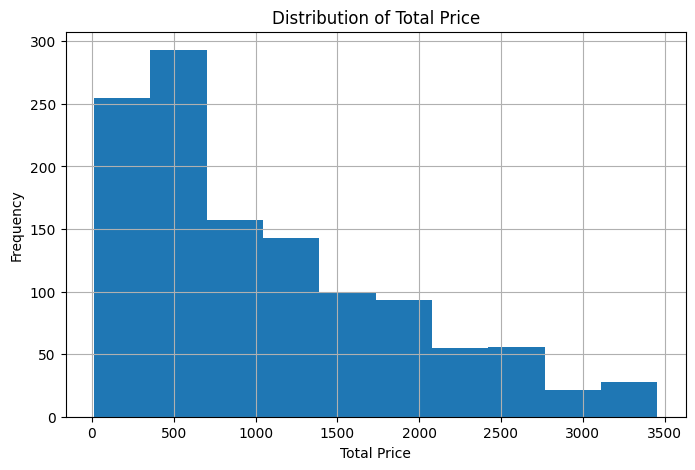

In [18]:
print("Identifying the distribution pattern:")
df['TotalPrice'].hist(figsize=(8,5))
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.title("Distribution of Total Price")
plt.show()


In [21]:
print("Detecting outlier using the Interquartile Range:")
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]
print("Outliers:")
print(outliers)
print("Total outliers:", outliers.shape[0])

Detecting outlier using the Interquartile Range:
Outliers:
        OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
107   ORD200107 2023-03-27     C16775  Printer         5     670.75   
326   ORD200326 2024-07-01     C65986   Laptop         5     670.48   
328   ORD200328 2023-02-28     C18404   Tablet         5     674.04   
469   ORD200469 2023-11-26     C13877    Chair         5     676.98   
632   ORD200632 2023-05-02     C67260   Laptop         5     678.16   
789   ORD200789 2023-08-17     C57276   Tablet         5     691.28   
1065  ORD201065 2023-10-30     C47778  Printer         5     666.80   
1122  ORD201122 2023-06-07     C38840  Monitor         5     678.19   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
107      848 Main St     Gift Card     Shipped    TRK34392124            8   
326      273 Main St     Gift Card    Returned    TRK98353867            5   
328      546 Main St        Online   Cancelled    TRK89401624      

Detect Outlier:


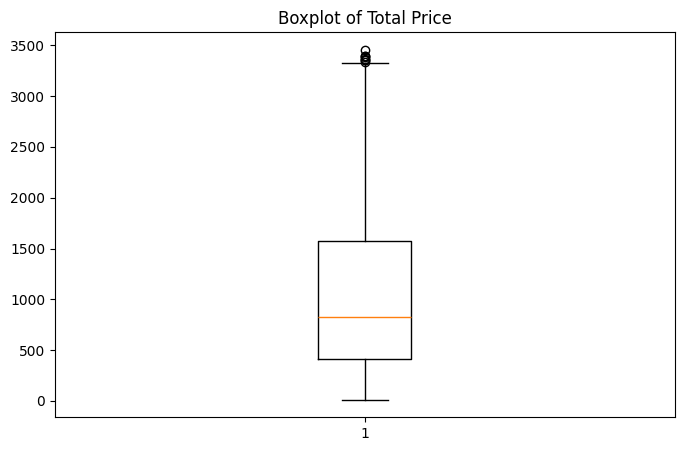

In [19]:
print("Detect Outlier using the boxplot:")
plt.figure(figsize=(8,5))
plt.boxplot(df['TotalPrice'])
plt.title("Boxplot of Total Price")
plt.show()

In [22]:
print("Trend analysis using the Total sales by payment method:")
df.groupby('PaymentMethod')['TotalPrice'].sum()


Trend analysis using the Total sales by payment method:


,TotalPrice
PaymentMethod,
Cash,259786.29
Credit Card,263847.63
Debit Card,232361.18
Gift Card,246323.92
Online,262442.94


In [23]:
print("most sold Products:")
df["Product"].value_counts()

most sold Products:


,count
Product,
Printer,181
Tablet,179
Chair,178
Laptop,173
Desk,170
Monitor,163
Phone,156


In [24]:
print("Order status Analysis:")
df["OrderStatus"].value_counts()

Order status Analysis:


,count
OrderStatus,
Cancelled,250
Returned,247
Pending,237
Shipped,235
Delivered,231


In [26]:
print("saved final results:")
df.to_excel("EDA_output.xlsx", index=False)

saved final results:
